# 03 — Results Analysis
Compare all models across reconstruction, clinical, and generation metrics.

In [5]:
import os
os.chdir('/workspace/ACDC-demo')



In [6]:
import sys; sys.path.insert(0, '..')
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

results_dir = Path('results')
recon = json.loads((results_dir / 'reconstruction.json').read_text())
df = pd.DataFrame(recon).T
print(df)

      chamfer_mean  chamfer_std  hausdorff_mean  hausdorff_std
pca       8.404865     1.039739       32.428709       1.120542
main      0.994917     0.077140        1.613810       0.100136


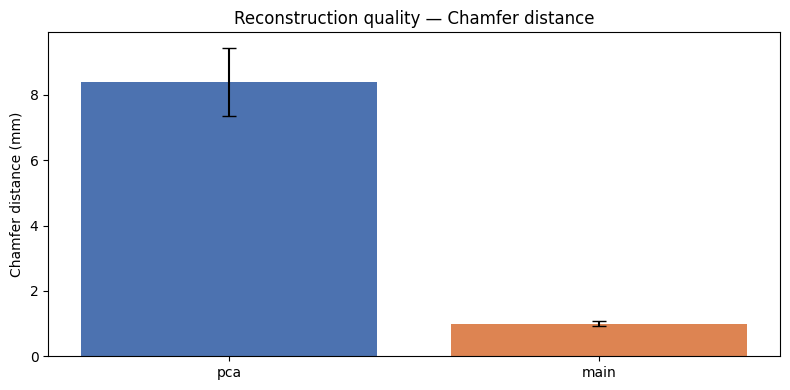

In [8]:
# Bar chart: Chamfer distance per model
fig, ax = plt.subplots(figsize=(8, 4))
models = list(recon.keys())
chamfers = [recon[m]['chamfer_mean'] for m in models]
errs = [recon[m]['chamfer_std'] for m in models]
ax.bar(models, chamfers, yerr=errs, capsize=5, color=['#4c72b0','#dd8452','#55a868','#c44e52'])
ax.set_ylabel('Chamfer distance (mm)')
ax.set_title('Reconstruction quality — Chamfer distance')
plt.tight_layout()
plt.savefig('report/figures/chamfer_comparison.png', dpi=150)